In [1]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True
DATA_PATH = r"kod\data\processed\mereni.parquet"
TEMP_PATH = r"kod\data\processed\mereni.tmp.parquet"

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema)
if PRINT: describe(df, True)

CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_J1939_AC_Podporovano,Obd_Readiness_J1939_AC_Otestovano,Obd_Readiness_J1939_BOOST_Podporovano,Obd_Readiness_J1939_BOOST_Otestovano,Obd_Readiness_J1939_CAT-FUNC_Podporovano,Obd_Readiness_J1939_CAT-FUNC_Otestovano,Obd_Readiness_J1939_COLD_Podporovano,Obd_Readiness_J1939_COLD_Otestovano,Obd_Readiness_J1939_COMP_Podporovano,Obd_Readiness_J1939_COMP_Otestovano,Obd_Readiness_J1939_DPF_Podporovano,Obd_Readiness_J1939_DPF_Otestovano,Obd_Readiness_J1939_EGR-VVT_Podporovano,Obd_Readiness_J1939_EGR-VVT_Otestovano,Obd_Readiness_J1939_EGS-FUNC_Podporovano,Obd_Readiness_J1939_EGS-FUNC_Otestovano,Obd_Readiness_J1939_EGS-HEAT_Podporovano,Obd_Readiness_J1939_EGS-HEAT_Otestovano,Obd_Readiness_J1939_EVAP_Podporovano,Obd_Readiness_J1939_EVAP_Otestovano,Obd_Readiness_J1939_FUEL_Podporovano,Obd_Readiness_J1939_FUEL_Otestovano,Obd_Readiness_J1939_HCAT_Podporovano,Obd_Readiness_J1939_HCAT_Otestovano,Obd_Readiness_J1939_MISF_Podporovano,Obd_Readiness_J1939_MISF_Otestovano,Obd_Readiness_J1939_NM-HC_Podporovano,Obd_Readiness_J1939_NM-HC_Otestovano,Obd_Readiness_J1939_NOX_Podporovano,Obd_Readiness_J1939_NOX_Otestovano,Obd_Readiness_J1939_SAS_Podporovano,Obd_Readiness_J1939_SAS_Otestovano,Benzin_Palivo,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_Otacky

(20537568, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-420930-19-01-0001,2019-01-01,420930,2019-01-01T14:43:55.0200000+01:00,2019-01-01T15:06:04.3900000+01:00,47287,CZ-420930-19-01-0001,2019-01-01T14:51:00,ActiaCZ,AT605,...,None,None,None,None,None,None,None,None,None,None
1,CZ-520406-19-01-0001,2019-01-01,520406,2019-01-01T15:22:33.2900000+01:00,2019-01-01T15:39:51.5500000+01:00,16835,CZ-520406-19-01-0001,2019-01-01T15:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,None,None,None
2,CZ-170901-23-01-0002,2023-01-01,170901,2023-01-01T19:42:08.8770000+01:00,2023-01-01T19:53:03.3100000+01:00,89493,CZ-170901-23-01-0002,2023-01-01T19:50:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
3,CZ-480811-23-01-0001,2023-01-01,480811,2023-01-01T12:22:13.5700000+01:00,2023-01-01T12:36:18.7000000+01:00,36479,CZ-480811-23-01-0001,2023-01-01T12:33:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
4,CZ-420221-23-01-0001,2023-01-01,420221,2023-01-01T16:07:06.1270000+01:00,2023-01-01T16:17:16.0300000+01:00,44365,CZ-420221-23-01-0001,2023-01-01T16:17:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
5,CZ-420221-23-01-0003,2023-01-01,420221,2023-01-01T16:57:28.1900000+01:00,2023-01-01T17:06:11.8300000+01:00,44365,CZ-420221-23-01-0003,2023-01-01T17:05:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
6,CZ-170901-23-01-0001,2023-01-01,170901,2023-01-01T19:24:30.3070000+01:00,2023-01-01T19:36:25.5270000+01:00,89493,CZ-170901-23-01-0001,2023-01-01T19:32:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
7,CZ-420221-23-01-0004,2023-01-01,420221,2023-01-01T17:26:23.7170000+01:00,2023-01-01T17:41:10.1600000+01:00,44365,CZ-420221-23-01-0004,2023-01-01T17:40:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
8,CZ-520406-24-01-0001,2024-01-01,520406,2024-01-01T11:31:17.2900000+01:00,2024-01-01T11:48:07.5200000+01:00,1308,CZ-520406-24-01-0001,2024-01-01T11:38:00,AVL DiTEST GmbH,AVL Gas 1000,...,None,None,None,None,None,None,None,None,None,None
9,CZ-480811-24-01-0001,2024-01-01,480811,2024-01-01T16:22:23.1070000+01:00,2024-01-01T16:36:09.9300000+01:00,36479,CZ-480811-24-01-0001,2024-01-01T16:31:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None


# Přetypování sloupců

In [3]:
df = cast_mereni(df)

# Vyber mereni, ktera maji protejsek v prohlidkach (zajisteni stejnych filtru)

In [ ]:
lf_prohlidky = pl.scan_parquet(r'kod\data\extracted\prohlidky_vozidel_stk_a_sme\parquet', schema=prohlidky_schema)
id_prohlidky_series = lf_prohlidky.select('CisloProtokolu').unique().collect(engine='streaming').get_column('CisloProtokolu')

if PRINT:
    id_prohlidky = set(id_prohlidky_series)
    id_mereni = set(df.get_column('CisloProtokolu'))
    orphan = list(id_prohlidky - id_mereni)
    display(lf_prohlidky.filter(pl.col('CisloProtokolu').is_in(orphan)).collect(engine='streaming')['DatumProhlidky'].value_counts(sort=True))

df = df.join(id_prohlidky_series.to_frame("CisloProtokolu"), on="CisloProtokolu", how="semi")

DatumProhlidky,count
str,u32
"""2026-02-27""",9459
"""2023-11-02""",2
"""2024-02-15""",2
"""2024-11-15""",2
"""2024-11-20""",2
…,…
"""2022-07-26""",1
"""2023-07-28""",1
"""2022-11-29""",1


# Odstraneni nekterych sloupcu
### Rok_vyroby

In [6]:
if PRINT: print(f'Podil mereni, ktera maji rok vyroby mensi nez 1000: {len(df.filter(pl.col('Vozidlo_RokVyroby') < 1000)) / df.height * 100:.2f} %')

Podil mereni, ktera maji rok vyroby mensi nez 1000: 25.41 %


### Vysledek_RidiciJednotka

In [7]:
if PRINT: 
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 1)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 2)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 3)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])

['---', 'bez závad', '', None, 'Celkem 0 závad ', 'Bez závad', 'BEZ ZÁVAD', 'OK', 'ok', 'Nebyly zjištěny závady']
['---', None, '', 'BEZ ZÁVAD', 'bez závad', 'OK', 'registrované DTC nejsou emisně relevantní', 'Bez závad', 'BEZ ZAVAD', 'VYHOVUJE']
['---', None, 'emisně relevantní závady', '', 'Bez závad', 'Celkem 1 závada P0380', 'Celkem Chybová hlášení v paměti. závad ', 'Celkem 1 závada P0420', 'Celkem 1 závada P0401', 'Celkem 1 závada P0670']


### Obd_VypisDTC

In [9]:
if PRINT: 
    obd_vypis_dtc_non_null = df['Obd_VypisDtc'].filter(df['Obd_VypisDtc'].is_not_null())
    print(f'Podil, kdy obd vypis dtc neni null: {len(obd_vypis_dtc_non_null) / df.height * 100:.2f} %')
    print(obd_vypis_dtc_non_null.to_list()[:10])

Podil, kdy obd vypis dtc neni null: 3.19 %
[['P0263'], ['P2279'], ['P0401', 'P0113'], ['P1351', 'P0401', 'P0409', 'P1162', 'P0490'], ['P0046'], ['4364'], ['P0238', 'P2126', 'P0409', 'P1351', 'P1162', 'P0490'], ['P0420'], ['P2BAE', 'P2BAE', 'U041B', 'P2202', 'P2206', 'P2209', 'U1009'], ['P0403']]


### J1939
- Odstraneni radku, ktere hodnoty obsahuji

In [10]:
j1939_df = df.filter(
    pl.any_horizontal(
        pl.col("^.*J1939.*$").is_not_null()
    )
)
if PRINT: short_display(j1939_df)
# Modifikace df
df = df.join(j1939_df, on="CisloProtokolu", how="anti")

(122937, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-471025-19-02-0020,2019-02-01,471025,2019-02-01 15:46:41.467,2019-02-01 16:03:17.410,37829,CZ-471025-19-02-0020,2019-02-01 15:54:00,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,CZ-470326-19-02-0005,2019-02-01,470326,2019-02-01 18:41:28.243,2019-02-01 19:10:59.900,37965,CZ-470326-19-02-0005,2019-02-01 19:10:00,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,CZ-570316-19-02-0002,2019-02-01,570316,2019-02-01 19:42:01.057,2019-02-01 20:13:22.723,36507,CZ-570316-19-02-0002,2019-02-01 21:06:00,MAHA,MDO-2,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,CZ-420620-19-02-0040,2019-02-01,420620,2019-02-01 15:45:44.650,2019-02-01 15:51:37.700,47163,CZ-420620-19-02-0040,2019-02-01 15:47:00,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,CZ-560613-19-02-0020,2019-02-01,560613,2019-02-01 15:04:08.253,2019-02-01 15:12:10.327,21187,CZ-560613-19-02-0020,2019-02-01 15:04:10,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
5,CZ-540514-19-02-0121,2019-02-01,540514,2019-02-01 14:24:43.517,2019-02-01 14:32:21.287,34793,CZ-540514-19-02-0121,2019-02-01 14:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
6,CZ-540514-19-02-0123,2019-02-01,540514,2019-02-01 15:04:36.370,2019-02-01 15:13:38.030,34793,CZ-540514-19-02-0123,2019-02-01 15:08:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
7,CZ-530104-19-02-0035,2019-02-01,530104,2019-02-01 14:21:13.143,2019-02-01 14:29:20.410,40997,CZ-530104-19-02-0035,2019-02-01 14:24:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
8,CZ-540514-19-02-0111,2019-02-01,540514,2019-02-01 13:39:46.033,2019-02-01 13:47:25.997,6807,CZ-540514-19-02-0111,2019-02-01 13:37:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
9,CZ-530104-19-02-0029,2019-02-01,530104,2019-02-01 13:31:43.277,2019-02-01 13:43:21.083,49407,CZ-530104-19-02-0029,2019-02-01 13:37:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


### Plyn_PocetVyusteni

In [13]:
if PRINT: display(df['Plyn_PocetVyusteni'].value_counts())

Plyn_PocetVyusteni,count
i8,u32
1,526927
2,1581
0,19886120


### PristiProhlidka

In [14]:
if PRINT: display(df.filter(pl.col('PristiProhlidka').is_not_null())['Vysledek_Vyhovuje'].value_counts())

Vysledek_Vyhovuje,count
bool,u32
true,19871582


In [15]:
duplicate_cols = ['DatumProhlidky', 'Zahajeni', 'Ukonceni', 'OdpovednaOsoba', 'Prohlidka_DatumProhlidky', 'Vozidlo_Vin', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Vozidlo_CisloMotoru', 'Vozidlo_Odometer', 'Vozidlo_DatumPrvniRegistrace', 'Vozidlo_Palivo', 'Obd_Vin']
irrelevant_cols = ['Prohlidka_CisloProtokolu', 'Vozidlo_RokVyroby', 'Vysledek_RidiciJednotka', 'Vysledek_TesnostPlynovehoZarizeni', 'PristiProhlidka', 'Benzin_Palivo', 'Nafta_Palivo']
j1939_cols = ['Obd_Readiness_J1939_AC_Podporovano', 'Obd_Readiness_J1939_AC_Otestovano', 'Obd_Readiness_J1939_BOOST_Podporovano', 'Obd_Readiness_J1939_BOOST_Otestovano', 'Obd_Readiness_J1939_CAT-FUNC_Podporovano', 'Obd_Readiness_J1939_CAT-FUNC_Otestovano', 'Obd_Readiness_J1939_COLD_Podporovano', 'Obd_Readiness_J1939_COLD_Otestovano', 'Obd_Readiness_J1939_COMP_Podporovano', 'Obd_Readiness_J1939_COMP_Otestovano', 'Obd_Readiness_J1939_DPF_Podporovano', 'Obd_Readiness_J1939_DPF_Otestovano', 'Obd_Readiness_J1939_EGR-VVT_Podporovano', 'Obd_Readiness_J1939_EGR-VVT_Otestovano', 'Obd_Readiness_J1939_EGS-FUNC_Podporovano', 'Obd_Readiness_J1939_EGS-FUNC_Otestovano', 'Obd_Readiness_J1939_EGS-HEAT_Podporovano', 'Obd_Readiness_J1939_EGS-HEAT_Otestovano', 'Obd_Readiness_J1939_EVAP_Podporovano', 'Obd_Readiness_J1939_EVAP_Otestovano', 'Obd_Readiness_J1939_FUEL_Podporovano', 'Obd_Readiness_J1939_FUEL_Otestovano', 'Obd_Readiness_J1939_HCAT_Podporovano', 'Obd_Readiness_J1939_HCAT_Otestovano', 'Obd_Readiness_J1939_MISF_Podporovano', 'Obd_Readiness_J1939_MISF_Otestovano', 'Obd_Readiness_J1939_NM-HC_Podporovano', 'Obd_Readiness_J1939_NM-HC_Otestovano', 'Obd_Readiness_J1939_NOX_Podporovano', 'Obd_Readiness_J1939_NOX_Otestovano', 'Obd_Readiness_J1939_SAS_Podporovano', 'Obd_Readiness_J1939_SAS_Otestovano']
plyn_cols = ['Plyn_Palivo', 'Plyn_PocetVyusteni', 'Plyn_OtackyVolnobezne_CO_Max_Hodnota', 'Plyn_OtackyVolnobezne_CO_Max_RucniZadani', 'Plyn_OtackyVolnobezne_CO_Hodnota', 'Plyn_OtackyVolnobezne_CO_Vysledek', 'Plyn_OtackyVolnobezne_CO2_Hodnota', 'Plyn_OtackyVolnobezne_CO2_Vysledek', 'Plyn_OtackyVolnobezne_COCOOR_Hodnota', 'Plyn_OtackyVolnobezne_COCOOR_Vysledek', 'Plyn_OtackyVolnobezne_HC_Max_Hodnota', 'Plyn_OtackyVolnobezne_HC_Max_RucniZadani', 'Plyn_OtackyVolnobezne_HC_Hodnota', 'Plyn_OtackyVolnobezne_HC_Vysledek', 'Plyn_OtackyVolnobezne_LAMBDA_Min_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Min_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Max_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Max_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Vysledek', 'Plyn_OtackyVolnobezne_N_Min_Hodnota', 'Plyn_OtackyVolnobezne_N_Min_RucniZadani', 'Plyn_OtackyVolnobezne_N_Max_Hodnota', 'Plyn_OtackyVolnobezne_N_Max_RucniZadani', 'Plyn_OtackyVolnobezne_N_Hodnota', 'Plyn_OtackyVolnobezne_N_Vysledek', 'Plyn_OtackyVolnobezne_NOX_Hodnota', 'Plyn_OtackyVolnobezne_NOX_Vysledek', 'Plyn_OtackyVolnobezne_O2_Hodnota', 'Plyn_OtackyVolnobezne_O2_Vysledek', 'Plyn_OtackyVolnobezne_TPS_Hodnota', 'Plyn_OtackyVolnobezne_TPS_Vysledek', 'Plyn_OtackyZvysene_CO_Max_Hodnota', 'Plyn_OtackyZvysene_CO_Max_RucniZadani', 'Plyn_OtackyZvysene_CO_Hodnota', 'Plyn_OtackyZvysene_CO_Vysledek', 'Plyn_OtackyZvysene_CO2_Hodnota', 'Plyn_OtackyZvysene_CO2_Vysledek', 'Plyn_OtackyZvysene_COCOOR_Hodnota', 'Plyn_OtackyZvysene_COCOOR_Vysledek', 'Plyn_OtackyZvysene_HC_Max_Hodnota', 'Plyn_OtackyZvysene_HC_Max_RucniZadani', 'Plyn_OtackyZvysene_HC_Hodnota', 'Plyn_OtackyZvysene_HC_Vysledek', 'Plyn_OtackyZvysene_LAMBDA_Min_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Min_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Max_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Max_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Vysledek', 'Plyn_OtackyZvysene_N_Min_Hodnota', 'Plyn_OtackyZvysene_N_Min_RucniZadani', 'Plyn_OtackyZvysene_N_Max_Hodnota', 'Plyn_OtackyZvysene_N_Max_RucniZadani', 'Plyn_OtackyZvysene_N_Hodnota', 'Plyn_OtackyZvysene_N_Vysledek', 'Plyn_OtackyZvysene_NOX_Hodnota', 'Plyn_OtackyZvysene_NOX_Vysledek', 'Plyn_OtackyZvysene_O2_Hodnota', 'Plyn_OtackyZvysene_O2_Vysledek', 'Plyn_OtackyZvysene_TPS_Hodnota', 'Plyn_OtackyZvysene_TPS_Vysledek', 'Plyn_Nadrz_Vyrobce', 'Plyn_Nadrz_Homologace', 'Plyn_Nadrz_Zivotnost', 'Plyn_Nadrz_Kontrola']
df = df.drop(duplicate_cols + irrelevant_cols + j1939_cols + plyn_cols)

# Unikatnost cisla protokolu
- nasledne odstraneno stanice cislo

In [16]:
if PRINT: print(f'Délka datasetu před odstraněním duplicitních řádků: {df.height}')

df = df.unique()
if PRINT: print(f'Délka datasetu po odstranění duplicitních řádků: {df.height}')

non_unique = df.select(pl.col('CisloProtokolu')).filter(pl.col('CisloProtokolu').is_duplicated())['CisloProtokolu'].unique().to_list()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').is_in(non_unique)).sort(by=['CisloProtokolu', 'StaniceCislo']))

df = df.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo")))
if PRINT: print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {df.height}')
df = df.drop('StaniceCislo')

Délka datasetu před odstraněním duplicitních řádků: 20414628
Délka datasetu po odstranění duplicitních řádků: 20413791
(8, 202)


,CisloProtokolu,StaniceCislo,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vysledek_VisualniKontrola,Vysledek_Readiness,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-540308-24-02-0512,3420,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-540308-24-02-0512,540308,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-540308-24-02-0561,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CZ-540308-24-02-0561,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CZ-540308-24-02-0563,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-540308-24-02-0563,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-550309-23-06-0452,3521,MAHLE,OPA-100,-,None,2021.0.1,4,True,None,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0
7,CZ-550309-23-06-0452,550309,MAHLE,OPA-100,-,None,2021.0.1,4,True,None,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0


Délka datasetu po odstranění vsech duplicitnich cisel protokolu: 20413787


# Serazeni sloupcu podle textu prace

In [17]:
df = df.select([
    # Identifikace měření
    "CisloProtokolu",

    # Měřicí přístroj
    "MericiPristroj_Vyrobce",
    "MericiPristroj_Typ",
    "MericiPristroj_Verze",
    "MericiPristroj_OBD",
    "MericiPristroj_VerzeSoftware",

    # Výsledek měření
    "Vysledek_VisualniKontrola",
    "Vysledek_Readiness",
    "Vysledek_RidiciJednotkaStav",
    "Vysledek_Mil",
    "Vysledek_Vyhovuje",
    "Obd_Readiness_Vysledek",
    "Zavady",
    "Poznamky",

    # Emisní systém (rizenyOBD)
    "EmisniSystem",
    "Obd_KomunikacniProtokol",
    "Obd_KontrolaMil",
    "Obd_PocetDtc",
    "Obd_VypisDtc",
    "Obd_VzdalenostDtc",
    "Obd_CasDtc",
    *sorted([c for c in df.columns if "Obd_Readiness_Zazeh" in c]),
    *sorted([c for c in df.columns if "Obd_Readiness_Vznet" in c]),

    # Detail měření dle typu paliva - Benzin
    "Benzin_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyVolnobezne")]),
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyZvysene")]),

    # Detail měření dle typu paliva - Nafta
    "Nafta_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniVznetLimit")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniPrumer")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni0")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni1")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni2")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni3")])
])

In [18]:
if PRINT: schema_description(df)
df.write_parquet(r"kod\data\processed\mereni_tmp.parquet")

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-461119-23-03-0072,1 / 20 413 787,0 / 20 413 787,String
1,MericiPristroj_Vyrobce,Bosch,6 660 207 / 20 413 787,65 825 / 20 413 787,String
2,MericiPristroj_Typ,AT605,2 656 741 / 20 413 787,65 825 / 20 413 787,String
3,MericiPristroj_Verze,-,7 074 699 / 20 413 787,951 462 / 20 413 787,String
4,MericiPristroj_OBD,R+OBD,3 902 492 / 20 413 787,2 846 849 / 20 413 787,String
...,...,...,...,...,...
196,Nafta_Mereni3_OtackyVolnobezne_Vysledek,1,3 849 619 / 20 413 787,16 562 466 / 20 413 787,Int8
197,Nafta_Mereni3_TPS_Hodnota,0.0,2 141 550 / 20 413 787,17 787 543 / 20 413 787,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,2 571 776 / 20 413 787,17 787 543 / 20 413 787,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,754 834 / 20 413 787,17 203 643 / 20 413 787,Float32


# Chybejici hodnoty

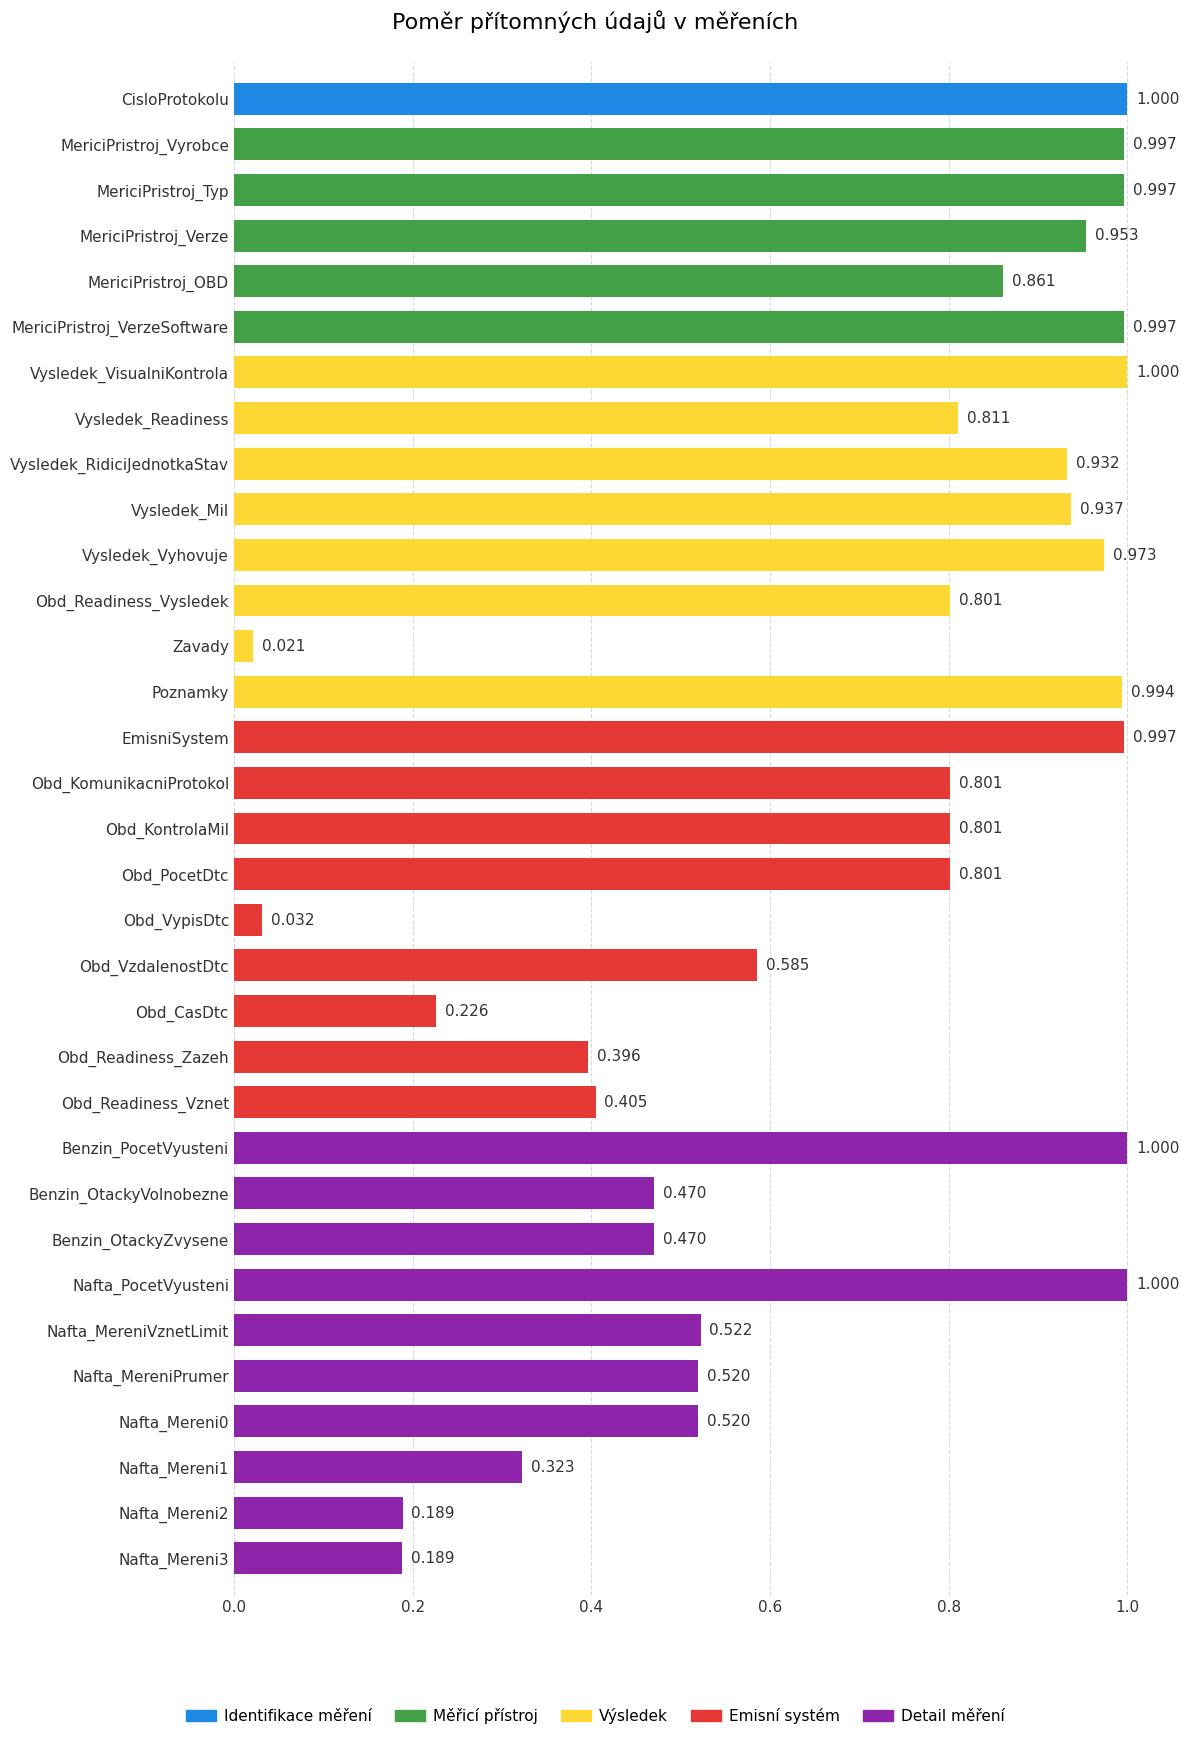

In [19]:
if PRINT: 
    # Definice agregačních skupin
    aggregation_groups = {
        'Obd_Readiness_Zazeh': [c for c in df.columns if 'Obd_Readiness_Zazeh' in c],
        'Obd_Readiness_Vznet': [c for c in df.columns if 'Obd_Readiness_Vznet' in c],
        'Benzin_OtackyVolnobezne': [c for c in df.columns if c.startswith('Benzin_OtackyVolnobezne_')],
        'Benzin_OtackyZvysene': [c for c in df.columns if c.startswith('Benzin_OtackyZvysene_')],
        'Nafta_MereniVznetLimit': [c for c in df.columns if c.startswith('Nafta_MereniVznetLimit_')],
        'Nafta_MereniPrumer': [c for c in df.columns if c.startswith('Nafta_MereniPrumer_')],
        'Nafta_Mereni0': [c for c in df.columns if c.startswith('Nafta_Mereni0_')],
        'Nafta_Mereni1': [c for c in df.columns if c.startswith('Nafta_Mereni1_')],
        'Nafta_Mereni2': [c for c in df.columns if c.startswith('Nafta_Mereni2_')],
        'Nafta_Mereni3': [c for c in df.columns if c.startswith('Nafta_Mereni3_')],
    }

    # Inverzní mapování: sloupec -> název skupiny
    col_to_group = {col: g_name for g_name, g_cols in aggregation_groups.items() for col in g_cols}

    # Výpočet metrik se zachováním pořadí z df.columns
    total_rows = len(df)
    final_labels = []
    final_ratios = []
    processed_groups = set()

    for col in df.columns:
        if col in col_to_group:
            group_name = col_to_group[col]
            if group_name not in processed_groups:
                # Výpočet pro celou skupinu (aspoň jedna ne-null hodnota)
                group_cols = aggregation_groups[group_name]
                any_present_count = df.select(
                    pl.any_horizontal(pl.col(group_cols).is_not_null())
                ).sum().item()
                final_labels.append(group_name)
                final_ratios.append(any_present_count / total_rows if total_rows > 0 else 0)
                processed_groups.add(group_name)
        else:
            # Samostatný sloupec
            non_null_count = total_rows - df[col].null_count()
            final_labels.append(col)
            final_ratios.append(non_null_count / total_rows if total_rows > 0 else 0)

    # Kategorizace (6 skupin včetně Vozidla)
    group_descriptions = [
        'Identifikace měření',
        'Měřicí přístroj',
        'Výsledek',  
        'Emisní systém', 
        'Detail měření'  
    ]

    def map_to_main_category(label):
        if label == 'CisloProtokolu': return 0
        if label.startswith('MericiPristroj'): return 1
        if any(x in label for x in ['Vysledek', 'PristiProhlidka', 'Zavady', 'Poznamky']): return 2
        if label.startswith('EmisniSystem') or label.startswith('Obd'): return 3
        if label.startswith('Benzin') or label.startswith('Nafta'): return 4
        return 3

    group_indices = [map_to_main_category(l) for l in final_labels]

    # Generování grafu
    horizontal_bar(
        labels=final_labels, 
        counts=final_ratios, 
        title='Poměr přítomných údajů v měřeních', 
        save_path='kod/explorace/mereni_grafy/mereni_pritomnost.svg', 
        decimals=3, 
        height=18, 
        group_indices=group_indices, 
        group_descriptions=group_descriptions
    )

### Emisni systemy

In [20]:
if PRINT: display(df['EmisniSystem'].value_counts(sort=True).with_columns(pl.col('count') / df.height))

EmisniSystem,count
enum,f64
"""Rizeny_Obd""",0.801281
"""Rizeny""",0.161724
"""Nerizeny""",0.03377
null,0.003225


### Pocet mereni u nafty

In [21]:
if PRINT: 
    print(f'Pomer dieselu, co ma alespon 2 mereni: {0.264 / 0.456 * 100:.2f} %')
    print(f'Pomer dieselu, co ma 3 a 4 mereni: {0.146 / 0.456 * 100:.2f} %')

Pomer dieselu, co ma alespon 2 mereni: 57.89 %
Pomer dieselu, co ma 3 a 4 mereni: 32.02 %


# Ulozeni dat

In [22]:
df.write_parquet(DATA_PATH)

In [23]:
df = pl.read_parquet(DATA_PATH)

# Odstraneni chybnych zaznamu
## Zaporne hodnoty

In [24]:
if PRINT: print(f'Pocet zaznamu se zapornou hodnou {df.filter(pl.any_horizontal(cs.numeric() < 0)).height}')
df = df.filter(pl.any_horizontal(~(cs.numeric() < 0)))

Pocet zaznamu se zapornou hodnou 7888


## Filtrace zaznamu predstavujicich konkretni mereni pro benzin nebo naftu

In [25]:
required_benzin = [
    # Benzin Vždy (Volnoběžné)
    "Benzin_OtackyVolnobezne_CO_Hodnota",
    "Benzin_OtackyVolnobezne_CO_Max_Hodnota",
    "Benzin_OtackyVolnobezne_N_Hodnota",
    "Benzin_OtackyVolnobezne_N_Min_Hodnota",
    "Benzin_OtackyVolnobezne_N_Max_Hodnota",
    
    # Benzin Zvýšené
    "Benzin_OtackyZvysene_LAMBDA_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota",
    "Benzin_OtackyZvysene_CO_Max_Hodnota",
    "Benzin_OtackyZvysene_N_Hodnota",
    "Benzin_OtackyZvysene_N_Min_Hodnota",
    "Benzin_OtackyZvysene_N_Max_Hodnota"
]

required_nafta = [
    # Nafta Průměr
    "Nafta_MereniPrumer_CasAkcelerace_Hodnota",
    "Nafta_MereniPrumer_Kourivost_Hodnota",
    "Nafta_MereniPrumer_OtackyVolnobezne_Hodnota",
    "Nafta_MereniPrumer_OtackyPrebehove_Hodnota",
    
    # Nafta Limit Max
    "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota",
    "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota",
    
    # Nafta Limit Min
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota"
]

benzin_mask = pl.all_horizontal(pl.col(required_benzin).is_not_null())
nafta_mask = pl.all_horizontal(pl.col(required_nafta).is_not_null())
if PRINT:
    print(f'Pocet neuplnych zaznamu: {df.filter(~(benzin_mask | nafta_mask)).height}')
    print(f'Pocet zaznamu s benzinem i naftou: {df.filter((pl.col('Nafta_PocetVyusteni') > 0) & (pl.col('Benzin_PocetVyusteni') > 0)).height}')
df = df.filter(benzin_mask | nafta_mask)

Pocet neuplnych zaznamu: 227669
Pocet zaznamu s benzinem i naftou: 0


## Kontrola limitu
### Benzin

In [26]:
limits_bounds_benzin = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Benzin_OtackyVolnobezne_CO_Max_Hodnota', 0.05, 5.0),
    ('Benzin_OtackyVolnobezne_N_Min_Hodnota', 300, 3000),
    ('Benzin_OtackyVolnobezne_N_Max_Hodnota', 300, 3000),
    ('Benzin_OtackyZvysene_CO_Max_Hodnota', 0.1, 1.0),
    ('Benzin_OtackyZvysene_LAMBDA_Min_Hodnota', 0.9, 1.00),
    ('Benzin_OtackyZvysene_LAMBDA_Max_Hodnota', 1.00, 1.1),
    ('Benzin_OtackyZvysene_N_Min_Hodnota', 1000, 10000),
    ('Benzin_OtackyZvysene_N_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_benzin:
    if PRINT: print(f'Pocet hodnot mimo limit pro {limit_bound[0]}: {df.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height}')
    df = df.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | nafta_mask)

Pocet hodnot mimo limit pro Benzin_OtackyVolnobezne_CO_Max_Hodnota: 18874
Pocet hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Min_Hodnota: 652
Pocet hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Max_Hodnota: 426
Pocet hodnot mimo limit pro Benzin_OtackyZvysene_CO_Max_Hodnota: 103107
Pocet hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Min_Hodnota: 18673
Pocet hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 3722
Pocet hodnot mimo limit pro Benzin_OtackyZvysene_N_Min_Hodnota: 314
Pocet hodnot mimo limit pro Benzin_OtackyZvysene_N_Max_Hodnota: 732


### Nafta

In [27]:
limits_bounds_nafta = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota', 0.1, 10.0),
    ('Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 0.1, 3.0),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota', 1000, 10000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_nafta:
    if PRINT: print(f'Pocet hodnot mimo limit pro {limit_bound[0]}: {df.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height}')
    df = df.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | benzin_mask)

Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota: 761
Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_Kourivost_Max_Hodnota: 325466
Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota: 371
Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 120
Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota: 1160
Pocet hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 1394


### Nesmyslne delky intervalu

In [28]:
# Seznam dvojic limitů pro kontrolu integrity
check_limits_integrity = [
    ("Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

for min_col, max_col in check_limits_integrity:
    if PRINT: print(f'Pocet hodnot se zapornou nebo nulovou delkou intervalu {min_col}, {max_col}: {df.filter(pl.col(min_col) >= pl.col(max_col)).height}')
    df = df.filter((pl.col(min_col).ne(pl.col(max_col))).fill_null(True))

Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyVolnobezne_N_Min_Hodnota, Benzin_OtackyVolnobezne_N_Max_Hodnota: 19
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_LAMBDA_Min_Hodnota, Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 4
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_N_Min_Hodnota, Benzin_OtackyZvysene_N_Max_Hodnota: 363
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota, Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 46
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota, Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 138


## Pro dalsi analyzu uvazovany pouze Rizene emisni systemy
- odstraneny i zaznamy, ktere maji skoro same null (pro analyzu vsak mene relevantni - pouze jako vysledek)
- diky tomu neni mereno HC

In [29]:
if PRINT: print(f'Podil rizenych: {df['EmisniSystem'].value_counts().filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))['count'].sum() / df.height * 100:.2f} %')
df = df.filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))
# EmisniSystem uz obsahoval pouze 2 hodnoty
df = df.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

Podil rizenych: 97.72 %


## Filtrace pouze uspesnych mereni

In [30]:
if PRINT: print(f'Podil uspesnych: {df.filter(pl.col('Vysledek_Vyhovuje') == True).height / df.height * 100:.2f} %')
df = df.filter(pl.col('Vysledek_Vyhovuje') == True).drop('Vysledek_Vyhovuje')

Podil uspesnych: 97.78 %


# Extrakce dulezitych informaci

## Normalizace hodnot

In [31]:
# Definice mapování pro normalizaci
all_mappings = [
    ("Benzin_OtackyVolnobezne_CO_Hodnota", None, "Benzin_OtackyVolnobezne_CO_Max_Hodnota"),
    ("Benzin_OtackyVolnobezne_N_Hodnota", "Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_CO_Hodnota", None, "Benzin_OtackyZvysene_CO_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Hodnota", "Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniPrumer_CasAkcelerace_Hodnota", None, "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota"),
    ("Nafta_MereniPrumer_Kourivost_Hodnota", None, "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyVolnobezne_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyPrebehove_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

exprs = []
for val_col, min_col, max_col in all_mappings:
    low = pl.col(min_col) if min_col else pl.lit(0)
    high = pl.col(max_col)
    val = pl.col(val_col)
    
    # Normalizace
    norm_expr = ((val - low) / (high - low)).alias(f"{val_col}_Norm")
    exprs.append(norm_expr)

df = df.with_columns(exprs).drop((cs.starts_with('Benzin_') | cs.starts_with('Nafta_')) & (~cs.ends_with('PocetVyusteni')) & (~cs.ends_with('_Norm')))

## Spojeni informaci o mericim pristroji do Vyrobce a Typu

In [32]:
df = df.with_columns((pl.col('MericiPristroj_Vyrobce') + pl.col('MericiPristroj_Typ')).alias('MericiPristroj_Info')).drop(cs.contains("MericiPristroj") & (~cs.by_name("MericiPristroj_Info")))

## Pro nizkou ruznorodost ponechano pouze Obd_PocetDtc z DTC

In [33]:
df = df.drop(cs.contains('Dtc') & (~cs.by_name('Obd_PocetDtc')))

## Readiness podpory a otestovani prevedeno do poctu True

In [34]:
df = df.with_columns(pl.sum_horizontal(cs.ends_with("_Podporovano")).alias("Pocet_Podporovano"), pl.sum_horizontal(cs.ends_with("_Otestovano")).alias("Pocet_Otestovano"))
df = df.drop((cs.ends_with("_Podporovano") | cs.ends_with("_Otestovano")) & (~cs.by_name("Pocet_Podporovano")) & (~cs.by_name("Pocet_Otestovano")))

## Redukce seznamů na pocet prvku

In [35]:
df = df.with_columns(pl.col('Poznamky').list.len().fill_null(0), pl.col('Zavady').list.len().fill_null(0))

## Ulozeni mezivypoctu

In [36]:
df.write_parquet(r"kod\data\processed\mereni_small.parquet")

# Analyza zpracovaneho datasetu

In [37]:
PRINT=True
df = pl.read_parquet(r'kod/data/processed/mereni_small.parquet')
df_benzin = df.filter(pl.col('Benzin_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Benzin_'))
df_nafta = df.filter(pl.col('Nafta_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Nafta_'))

## Rozdeleni a prazdne hodnoty

In [38]:
if PRINT:
    display(df_benzin.describe())
    display(df_nafta.describe())

statistic,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm
str,f64,f64,f64,f64,f64
"""count""",9.211221e6,9.211221e6,9.211221e6,9.211221e6,9.211221e6
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.132467,0.512855,0.606595,0.332199,0.465921
"""std""",0.504292,0.227972,11.123372,0.399531,0.303914
"""min""",-0.54,-15.5,-33.000031,-0.2,-40.0
"""25%""",0.0,0.4,0.483334,0.05,0.255
"""50%""",0.04,0.5,0.55,0.2,0.455
"""75%""",0.166667,0.605,0.7,0.58,0.66625
"""max""",920.0,144.5,17050.517578,633.333313,100.900002


statistic,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm
str,f64,f64,f64,f64
"""count""",9.622483e6,9.622483e6,9.622483e6,9.622483e6
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.208062,0.28598,0.450777,0.461869
"""std""",0.305759,3.217053,0.358974,0.837889
"""min""",0.0,0.0,-39.5,-103.0
"""25%""",0.0,0.019608,0.327273,0.34
"""50%""",0.2,0.156863,0.496667,0.5
"""75%""",0.315,0.511811,0.55,0.65
"""max""",526.280029,9236.363281,77.0,220.399994


## Hodnoty mimo rozsah

In [39]:
def print_values_invalid(df):
    for col in df.columns:
        print(f'Relativni cetnost pozorovani {col} mimo rozsah <0, 1>: {df.filter(~pl.col(col).is_between(0, 1)).height / df.height * 100:.2f} %')

if PRINT:
    print_values_invalid(df_benzin)
    print_values_invalid(df_nafta)

Relativni cetnost pozorovani Benzin_OtackyVolnobezne_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyVolnobezne_N_Hodnota_Norm mimo rozsah <0, 1>: 1.17 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_N_Hodnota_Norm mimo rozsah <0, 1>: 3.37 %
Relativni cetnost pozorovani Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm mimo rozsah <0, 1>: 0.06 %
Relativni cetnost pozorovani Nafta_MereniPrumer_Kourivost_Hodnota_Norm mimo rozsah <0, 1>: 0.02 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm mimo rozsah <0, 1>: 0.89 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm mimo rozsah <0, 1>: 2.05 %


### Nekdy je to zpusobeno spatnym zaokrouhlenim, jindy ne

In [40]:
if PRINT:
    df_kourivost_mimo = df.filter(~pl.col('Nafta_MereniPrumer_Kourivost_Hodnota_Norm').is_between(0, 1))
    short_display(df_kourivost_mimo)
    example_ids = df_kourivost_mimo['CisloProtokolu'][:10].to_list()
    short_display(pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(pl.col('CisloProtokolu'), pl.col('^.*Kourivost.*$')).filter(pl.col('CisloProtokolu').is_in(example_ids)).collect(engine='streaming'))

(1565, 26)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano
0,CZ-580214-22-09-0393,True,True,1.0,2.0,True,0,3,True,ISO 15765,...,NaN,NaN,NaN,0.364000,2.040000,0.333333,0.566667,AVL DiTEST GmbHAVL DiSmoke 480,4,11
1,CZ-450915-22-03-0441,True,True,1.0,2.0,True,0,2,True,ISO 14230,...,NaN,NaN,NaN,0.580000,1.230000,0.350000,0.430000,AVL DiTEST GmbHAVL DiSmoke 480,3,9
2,CZ-450915-20-07-0532,True,True,1.0,2.0,True,0,2,True,ISO K-Line,...,NaN,NaN,NaN,0.282000,1.011494,0.355000,0.065000,BoschKTS540,2,11
3,CZ-472201-19-09-0031,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.524000,1.057143,0.430000,0.403333,BoschMTM-BEA,0,0
4,CZ-560307-25-04-0415,True,True,2.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.200000,1.080000,0.500000,0.980000,AVL DiTEST GmbHAVL DiSmoke 480,5,11
5,CZ-580214-22-09-0282,True,True,1.0,2.0,True,0,3,True,ISO 15765,...,NaN,NaN,NaN,0.272000,1.560000,0.300000,0.500000,AVL DiTEST GmbHAVL DiSmoke 480,8,11
6,CZ-520701-19-01-0300,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.406667,1.172727,0.350000,0.625000,AVL DiTEST GmbHAVL DiSmoke 480,1,11
7,CZ-450915-22-01-0119,True,True,1.0,2.0,True,0,3,True,ISO K-Line,...,NaN,NaN,NaN,0.326000,1.477778,0.885000,0.117500,BoschKTS540,3,11
8,CZ-470631-23-05-0526,True,None,1.0,2.0,None,0,8,False,None,...,NaN,NaN,NaN,0.196000,1.042857,0.444444,0.480000,AVL DiTEST GmbHAVL DiSmoke 480,0,0
9,CZ-180803-23-10-0018,True,False,1.0,2.0,True,0,3,True,ISO9141,...,NaN,NaN,NaN,0.468000,1.254902,0.500000,0.510000,MAHLEOPA-100,3,10


(10, 15)


,CisloProtokolu,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek
0,CZ-180803-23-10-0018,0.51,true,0.25,false,0.64,1,0.6,1,0.68,1,None,None,None,None
1,CZ-472201-19-09-0031,1.05,false,0.25,false,1.11,1,1.37,1,1.35,1,1.09,1,0.62,1
2,CZ-450915-22-01-0119,0.90,false,0.25,false,1.33,1,2.0,1,1.98,1,0.55,1,0.8,1
3,CZ-560307-25-04-0415,0.250,false,0.250,false,0.27,0,0.27,0,None,None,None,None,None,None
4,CZ-580214-22-09-0282,0.25,true,0.25,false,0.39,1,0.39,1,None,None,None,None,None,None
5,CZ-450915-22-03-0441,1.00,false,0.25,false,1.23,1,0.82,1,0.84,1,1.67,1,1.58,1
6,CZ-520701-19-01-0300,1.10,false,0.25,false,1.29,1,1.35,1,1.22,1,None,None,None,None
7,CZ-580214-22-09-0393,0.25,true,0.51,true,0.51,1,0.51,1,None,None,None,None,None,None
8,CZ-450915-20-07-0532,0.87,false,0.25,false,0.88,1,0.88,1,0.87,1,0.87,1,0.89,1
9,CZ-470631-23-05-0526,0.70,true,0.25,false,0.73,1,0.68,1,0.77,1,0.79,1,0.68,1


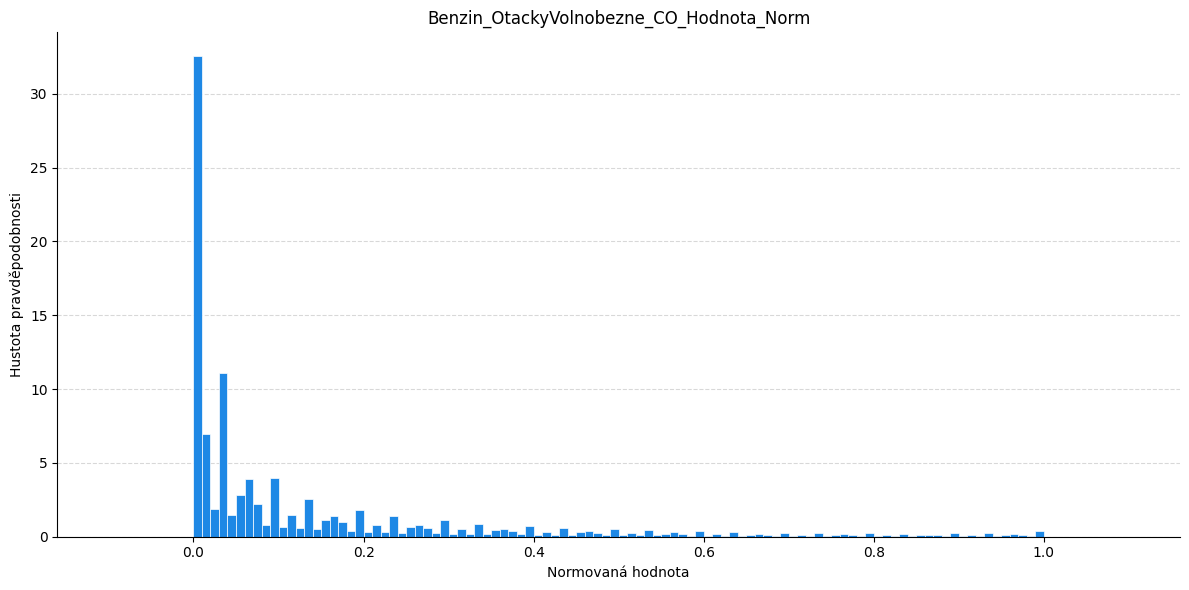

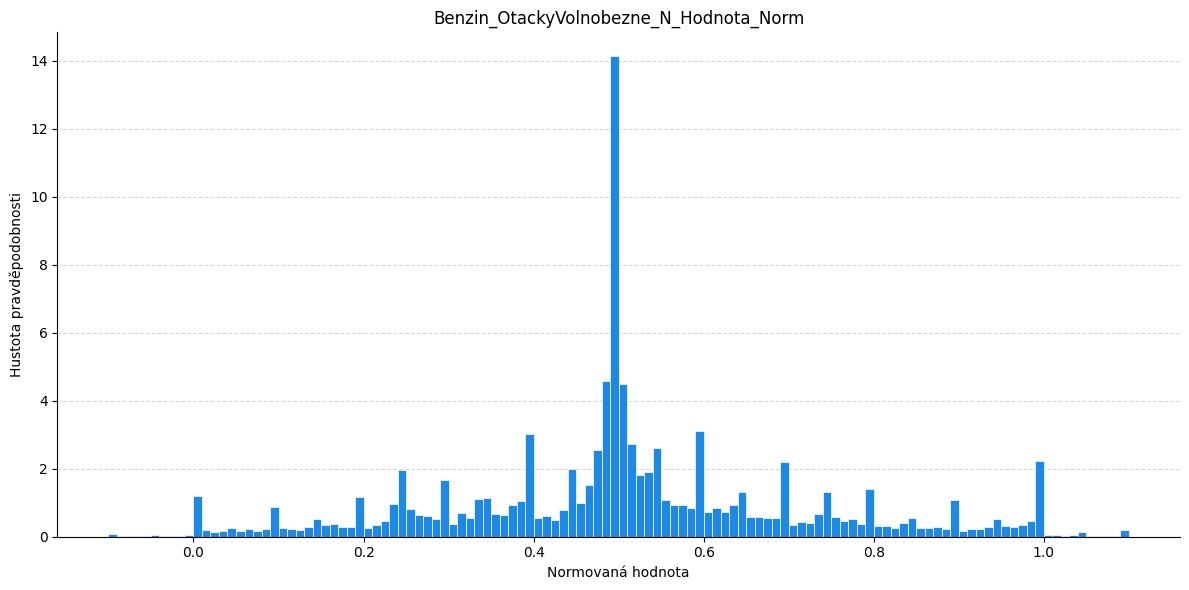

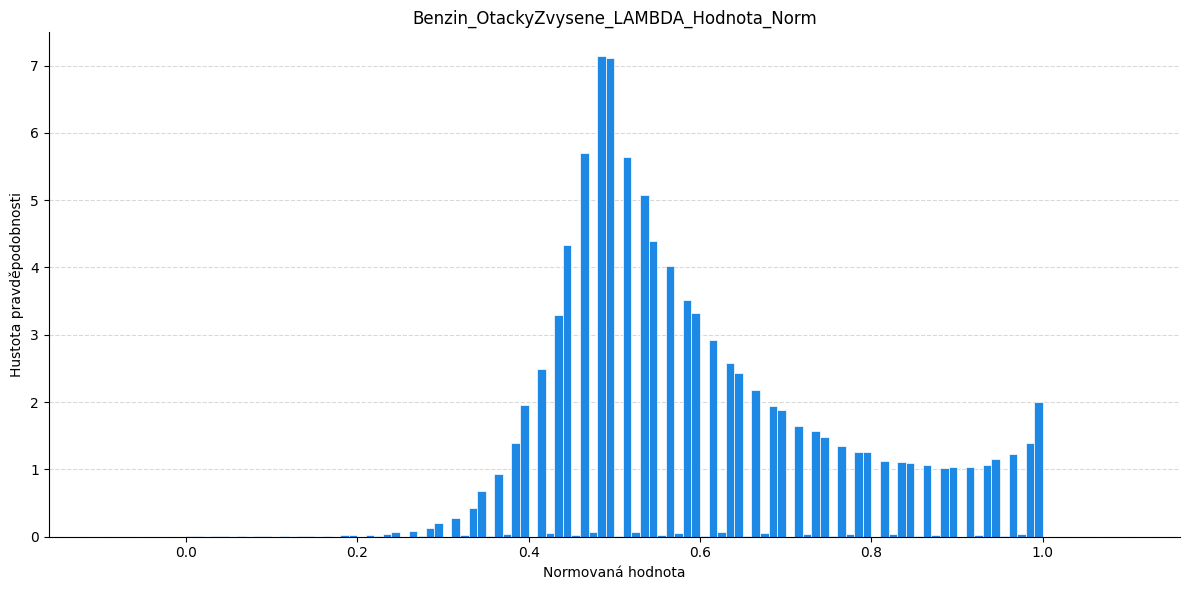

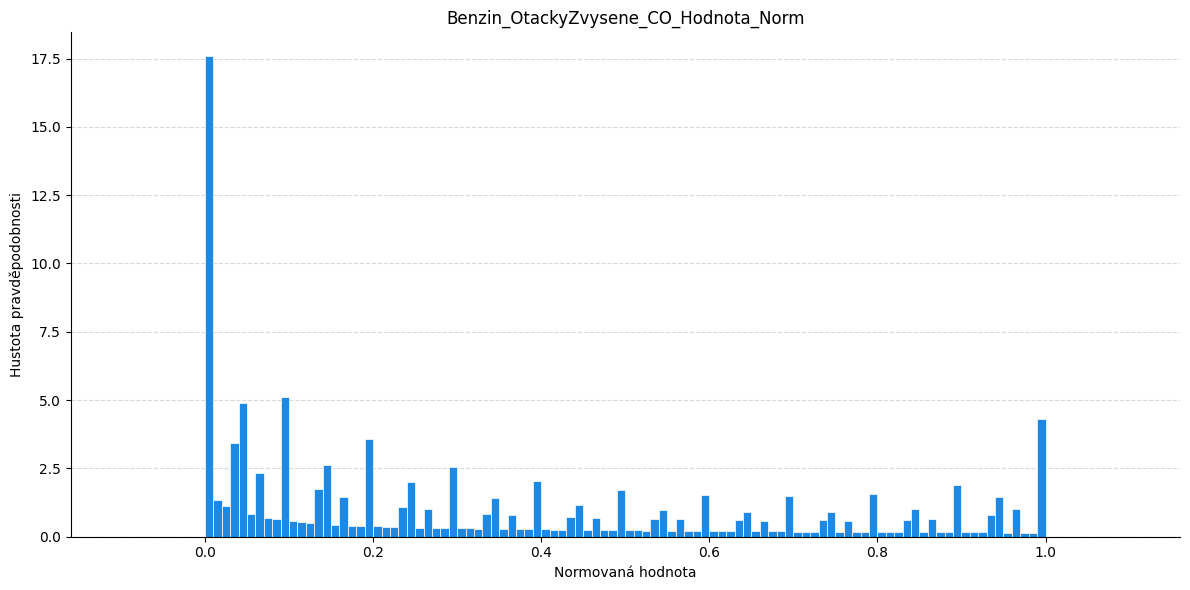

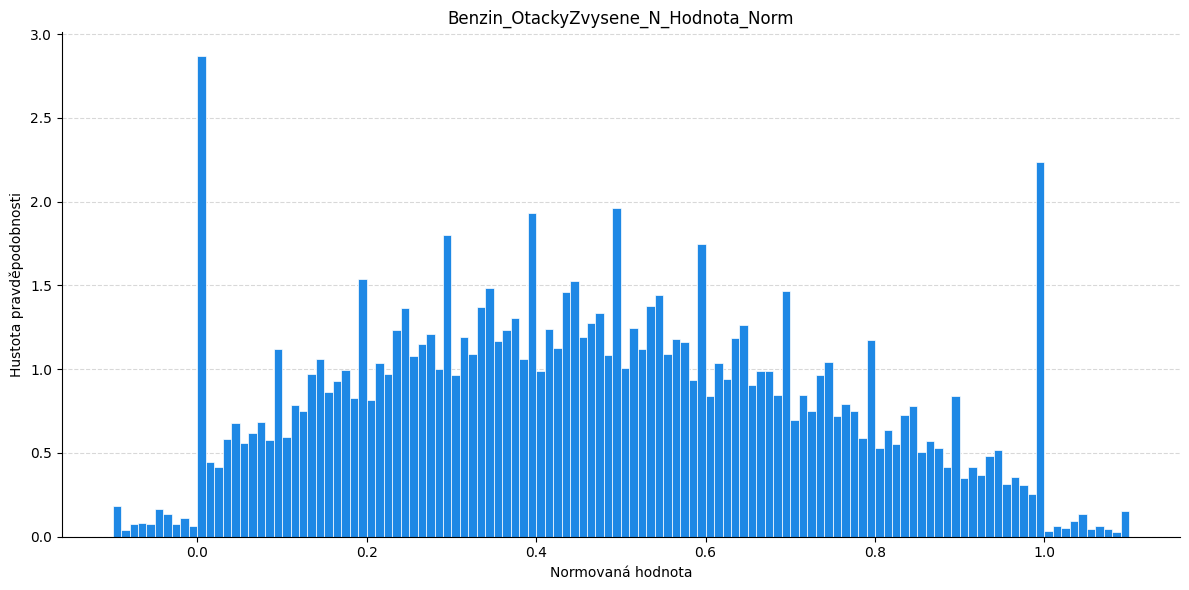

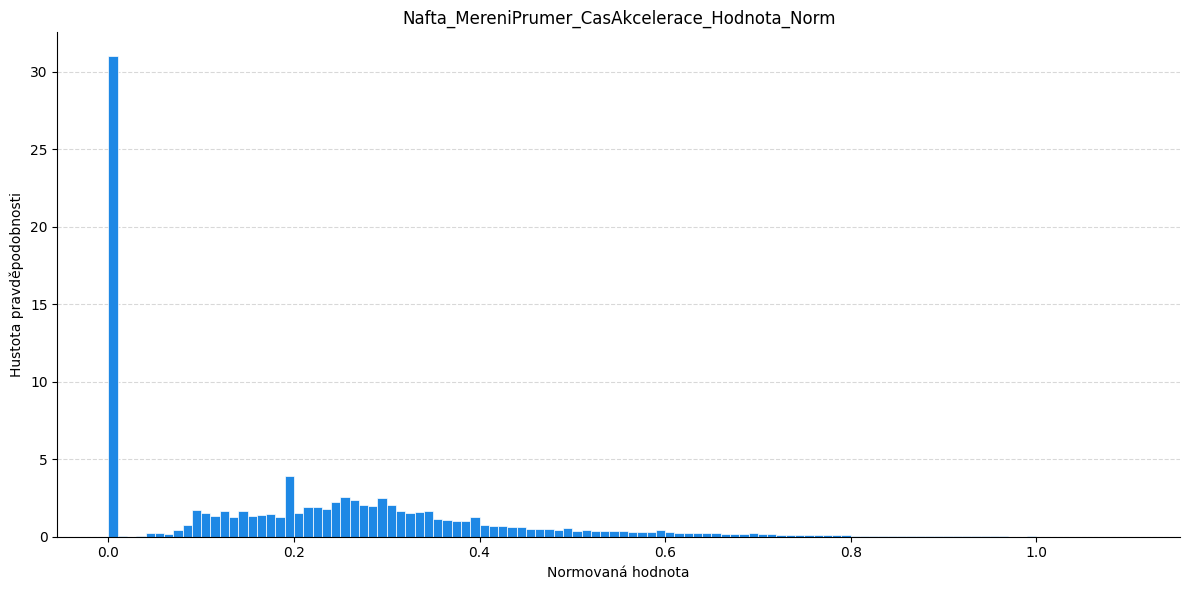

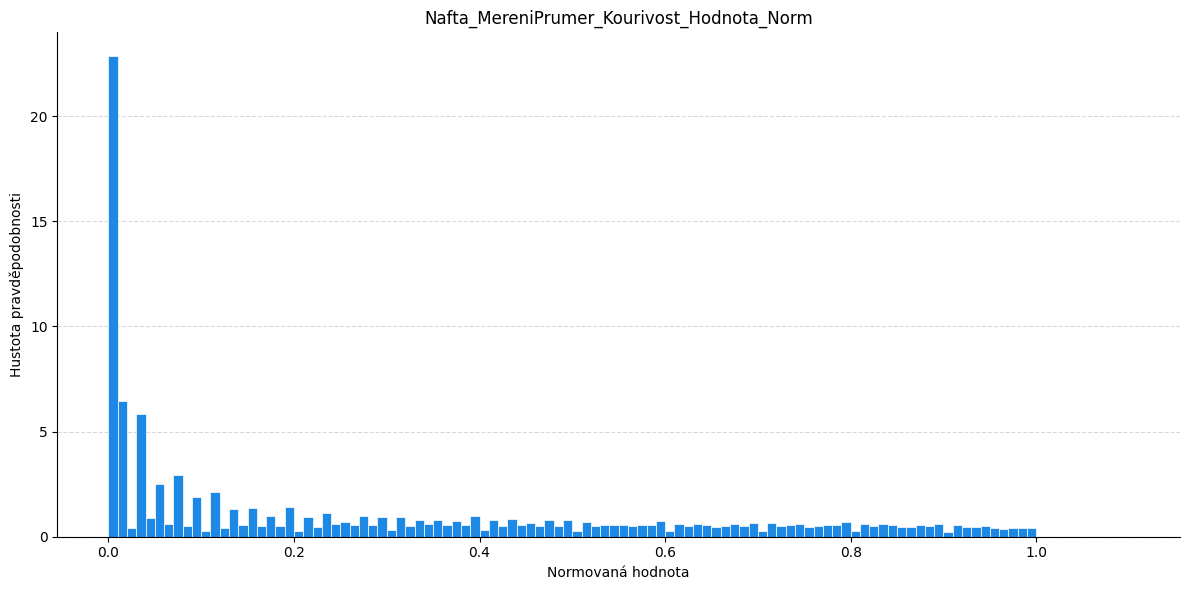

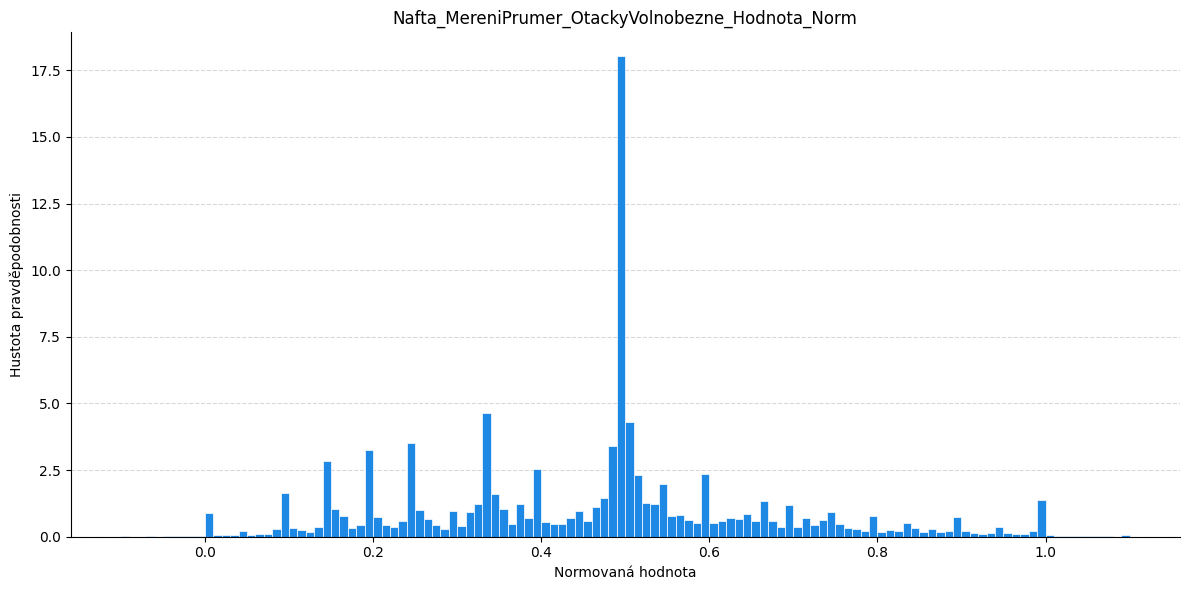

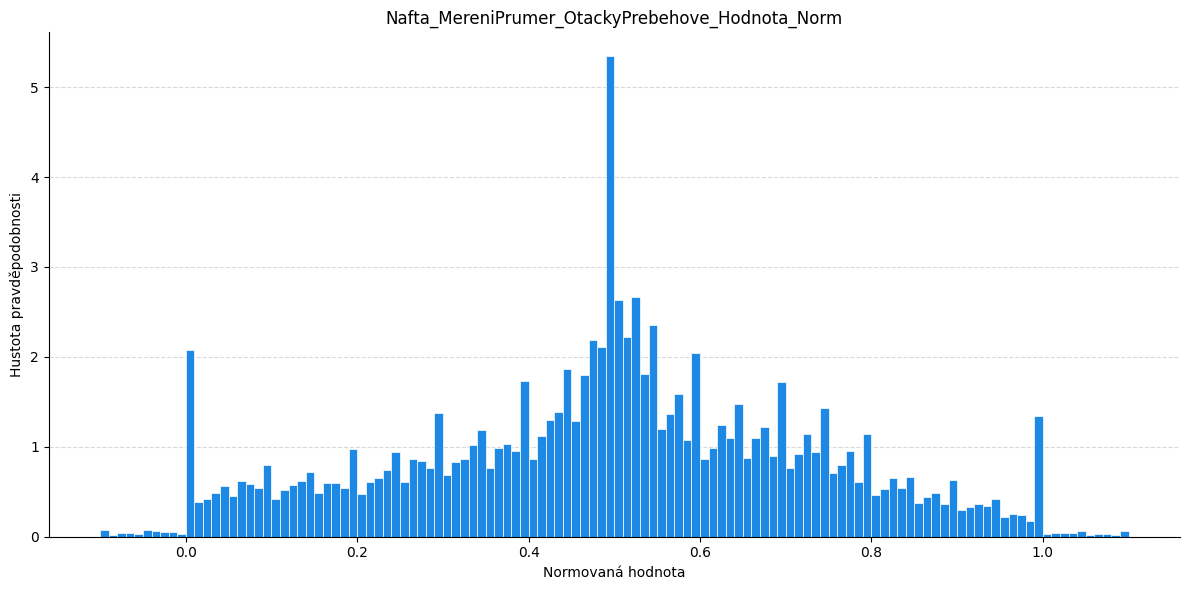

In [41]:
def plot_norms(df):
    for col in df.columns:
        distribution_density_plot(df.filter(pl.col(col).is_between(-0.1, 1.1)), col, col, 'Normovaná hodnota', 100, (0, 1.00001))
plot_norms(df_benzin)
plot_norms(df_nafta)

# Vývoj počtu anomálních měření v čase
- Hodnoty mimo povoleny rozsah, kde prohlidka presto skoncila uspesne
- Mereni, ktera maji hodnoty u kraje intervalu v definovanych merenich, kde je na to relativne mala sance

In [49]:
def time_series_preaggregated(x, y, title, y_title, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(x, y, marker=',' if len(x) > 10 else 'o')

    ax.set_title(title)
    ax.set_xlabel("Rok")
    ax.set_ylabel(y_title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom=0.0, top=y.max() * 1.1)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.4f'))
    
    fig.autofmt_xdate()

    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, format="svg", bbox_inches="tight")
 
    plt.show()

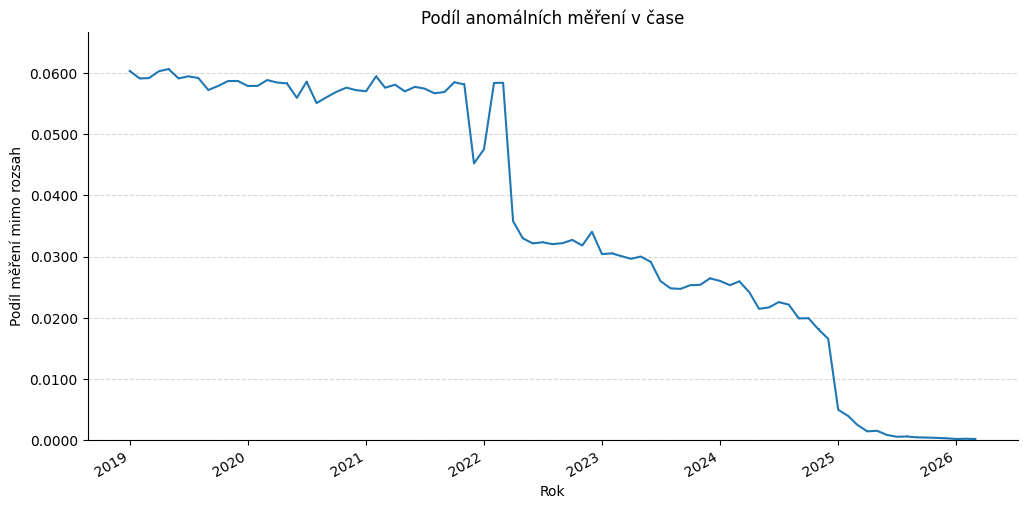

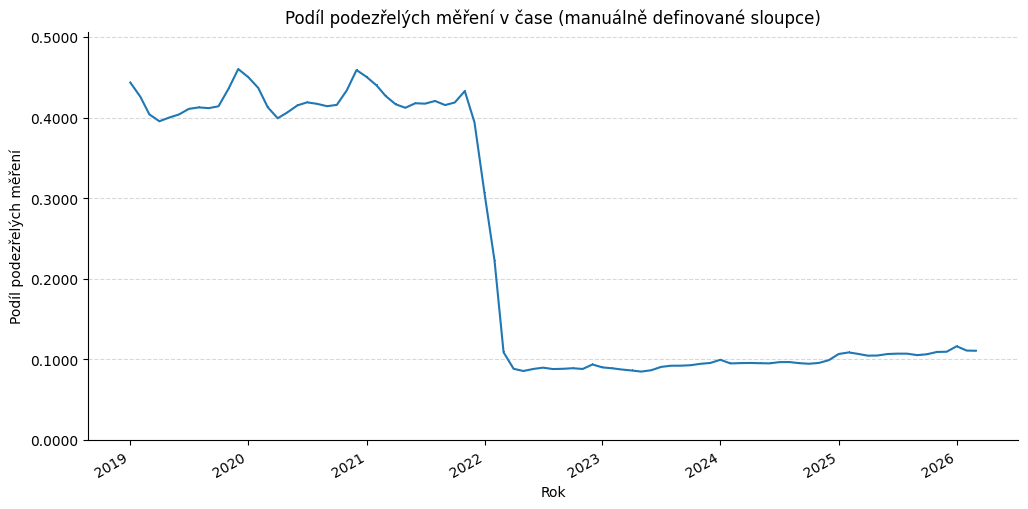

In [50]:
if PRINT:
    lf_time = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(['CisloProtokolu', 'Zahajeni'])
    
    df_base = (
        df.lazy()
        .join(lf_time, on='CisloProtokolu', how='left')
        .with_columns(pl.col('Zahajeni').cast(pl.Datetime).alias('ts'))
        .filter(pl.col('ts').is_not_null())
        .sort('ts')
    )

    # Anomální
    norm_cols = [c for c in df.columns if c.endswith('_Norm')]
    out_of_bounds_exprs = [(pl.col(c) < 0) | (pl.col(c) > 1) for c in norm_cols]
    
    df_anomalies_norm = (
        df_base
        .with_columns(pl.any_horizontal(out_of_bounds_exprs).fill_null(False).alias("Is_Anomalous"))
        .group_by_dynamic('ts', every='1mo')
        .agg((pl.col('Is_Anomalous').sum() / pl.len()).alias('Normalized'))
        .collect()
    )
    
    time_series_preaggregated(
        x=df_anomalies_norm['ts'], 
        y=df_anomalies_norm['Normalized'],
        title='Podíl anomálních měření v čase', 
        y_title='Podíl měření mimo rozsah', 
        save_path='kod/explorace/mereni_grafy/mereni_anomalie_cas.svg'
    )

    # Podezřelá
    epsilon = 0.01
    manual_cols = [
        'Benzin_OtackyVolnobezne_N_Hodnota_Norm', 
        'Benzin_OtackyZvysene_N_Hodnota_Norm', 
        'Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm', 
        'Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 
        'Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm'
    ]
    
    suspect_exprs = [
        pl.col(c).is_between(-epsilon, epsilon) | pl.col(c).is_between(1 - epsilon, 1 + epsilon) 
        for c in manual_cols
    ]
    
    df_suspect_norm = (
        df_base
        .with_columns(pl.any_horizontal(suspect_exprs).fill_null(False).alias("Is_Suspect"))
        .group_by_dynamic('ts', every='1mo')
        .agg((pl.col('Is_Suspect').sum() / pl.len()).alias('Normalized'))
        .collect()
    )
    
    time_series_preaggregated(
        x=df_suspect_norm['ts'], 
        y=df_suspect_norm['Normalized'],
        title='Podíl podezřelých měření v čase (manuálně definované sloupce)', 
        y_title='Podíl podezřelých měření', 
        save_path='kod/explorace/mereni_grafy/mereni_podezrela_cas.svg'
    )

# Finální příprava pro tvorbu modelu

## Sparovani pristich vysledku s merenimi

In [51]:
lf_full = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).pipe(cast_mereni)

lf_shifted_result = (
    lf_full
    .select(["CisloProtokolu", "Vozidlo_Vin", "Zahajeni", "Vysledek_Vyhovuje"])
    .sort(["Vozidlo_Vin", "Zahajeni"])
    .with_columns(
        Vysledek_Pristi_Raw=pl.col("Vysledek_Vyhovuje").shift(-1).over("Vozidlo_Vin"),
        Pristi_Zaznam_Existuje=pl.col("CisloProtokolu").shift(-1).over("Vozidlo_Vin").is_not_null()
    )
    .with_columns(
        Vysledek_Pristi=pl.when(pl.col("Pristi_Zaznam_Existuje"))
        .then(pl.col("Vysledek_Pristi_Raw").fill_null(False))
        .otherwise(None)
    )
    .select(["CisloProtokolu", "Vysledek_Pristi"])
)

df_model = (
    df.lazy()
    .join(
        lf_shifted_result,
        on="CisloProtokolu",
        how="left"
    )
    .collect()
)

## Odstraneni mereni, ktera nemaji znamy pristi vysledek

In [52]:
if PRINT: display(df_model['Vysledek_Pristi'].value_counts())
df_model = df_model.filter(pl.col('Vysledek_Pristi').is_not_null())

Vysledek_Pristi,count
bool,u32
false,327235
true,11643443
null,6863795


# Ulozeni dat pro trenovani modelu

In [53]:
df_model.write_parquet(r"kod\data\processed\mereni_model.parquet")

In [54]:
PRINT = True
if PRINT: describe(df_model)

CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Benzin_PocetVyusteni,Nafta_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
str,bool,bool,i8,i8,bool,u32,u32,bool,str,i8,i32,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,u32,u32,bool
"""CZ-460214-21-10-0677""",true,true,1,2,true,0,2,true,"""CAN (ISO 15765-4)""",2,0,1,0,0.0,0.336,0.633334,0.193333,0.268,null,null,null,null,"""BoschBEA055""",6,11,true


(11970678, 27)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
0,CZ-460214-21-10-0677,True,True,1.0,2.0,True,0,2,True,CAN (ISO 15765-4),...,0.193333,0.268000,NaN,NaN,NaN,NaN,BoschBEA055,6,11,True
1,CZ-451034-24-01-0194,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,0.338,0.403226,0.000000,0.6200,BoschBEA 950,2,11,True
2,CZ-560703-20-07-0101,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,NaN,NaN,0.000,0.000000,0.205000,0.1650,SUNDGA,6,11,True
3,CZ-450808-23-02-0027,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,0.000000,0.822000,NaN,NaN,NaN,NaN,BoschBEA060,7,11,True
4,CZ-570711-23-02-0148,True,False,1.0,2.0,False,0,2,True,ISO 14230 (KWP 2000 5-Baud),...,NaN,NaN,0.214,0.260000,0.500000,0.5225,ACTIA CZ s.r.o.AT605,5,11,True
5,CZ-520701-20-12-0243,True,True,1.0,2.0,None,0,1,False,None,...,NaN,NaN,0.765,0.136364,0.120000,0.8125,AVL DiTEST GmbHAVL DiSmoke 480,0,0,True
6,CZ-461103-19-01-0163,True,True,1.0,2.0,True,0,3,True,ISO 15765,...,NaN,NaN,0.000,0.000000,0.333333,0.7400,ActiaCZAT605,6,11,True
7,CZ-421134-19-10-0468,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,0.900000,0.417500,NaN,NaN,NaN,NaN,ActiaCZAT505,6,11,True
8,CZ-451034-22-02-1157,True,False,1.0,2.0,True,0,2,True,ISO K-Line,...,0.426667,0.738333,NaN,NaN,NaN,NaN,BoschBEA060,4,9,True
9,CZ-480801-20-09-0213,True,True,1.0,2.0,True,0,3,True,ISO 15765,...,0.000000,-0.133333,NaN,NaN,NaN,NaN,AVL DiTEST GmbHAVL Gas 1000,7,11,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-530107-21-10-0415,2 / 11 970 678,0 / 11 970 678,String
1,Vysledek_VisualniKontrola,True,11 969 833 / 11 970 678,0 / 11 970 678,Boolean
2,Vysledek_Readiness,True,8 204 382 / 11 970 678,1 786 514 / 11 970 678,Boolean
3,Vysledek_RidiciJednotkaStav,1,11 440 392 / 11 970 678,403 516 / 11 970 678,Int8
4,Vysledek_Mil,2,11 416 201 / 11 970 678,547 193 / 11 970 678,Int8
5,Obd_Readiness_Vysledek,True,9 463 607 / 11 970 678,1 885 520 / 11 970 678,Boolean
6,Zavady,0,11 960 428 / 11 970 678,0 / 11 970 678,UInt32
7,Poznamky,2,3 957 637 / 11 970 678,0 / 11 970 678,UInt32
8,OBD_Pritomno,True,10 085 158 / 11 970 678,0 / 11 970 678,Boolean
9,Obd_KomunikacniProtokol,ISO 15765,4 005 796 / 11 970 678,1 885 520 / 11 970 678,String
